<div style="text-align: center"><img src="https://telematica.usm.cl/wp-content/themes/telematica-web/assets/img/header-usm.png" height="75"></div>

# Tarea 2 Módulos 1 y 2: Cifrado Simétrico
### Asignatura: Criptografía y Seguridad de la Información - TEL252 - 2026
#### _Docente y Autor : Berioska Contreras Vargas - berioska.contreras@usm.cl

* **Polinomios:** Pueden ser representados como una lista de coeficientes. Mediante las bibliotecas de Numpy podemos crear y modificar polinomios utilizando la clase Polynomials.  

| Referencia |
| :--- |
| [Polynomials in NumPy](https://numpy.org/doc/stable/reference/routines.polynomials.html) |

In [1]:
import numpy as np  
import numpy.polynomial as gf  
grado = 3
gf.Polynomial.basis(grado)

Polynomial([0., 0., 0., 1.], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

* **Coeficientes:** Un polinomio es tratado como una serie de potencias finitas. Por lo tanto, la serie es representada en un arreglo unidimensional basado en los coeficientes del polinomio. Cada serie es ordenada ascendentemente o de menor a mayor.

In [2]:
import numpy as np  
from numpy.polynomial import Polynomial as gf 
cf = [0,0,1]
Ax = gf.degree(cf)
mypoly = gf(cf)
print(type(mypoly))
print(mypoly.coef, mypoly.domain, mypoly.window)
print ('grado:', Ax)

z = gf.basis(deg=Ax, domain=[0,1], window=[0,1]) #
print(type(z))
print(z.coef, z.domain, z.window)

<class 'numpy.polynomial.polynomial.Polynomial'>
[0. 0. 1.] [-1.  1.] [-1.  1.]
grado: 2
<class 'numpy.polynomial.polynomial.Polynomial'>
[0. 0. 1.] [0. 1.] [0. 1.]


* **Adición:** Un polinomio permite representar un conjunto finito de enteros aceptando operaciones finitas.

In [3]:
import numpy as np  
from numpy.polynomial import Polynomial as gf 
ca = [1,1,1]
cb = [1,1,0,1]
pa = gf(ca)
pb = gf(cb)
pa + pb

Polynomial([2., 2., 1., 1.], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

* **Multiplicación:** Un campo $GF(x)$ es un conjunto finito de números que permite distintas operacionesa aritméticas.

In [4]:
import numpy as np  
from numpy.polynomial import Polynomial as gf 
ca = [1,1,1]
cb = np.flip([1,0,1])
pa = gf(ca)
pb = gf(cb)
pa * pb

Polynomial([1., 1., 2., 1., 1.], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

* **Aritmética Modular:** Las operaciones suma, resta y multiplicación se realizan en conjuntos, y todas las condiciones en $GF(x)$ son satisfechas para la adición y multiplicación como expresión modular.

In [5]:
import numpy as np
from numpy.polynomial import Polynomial as gf 
def mymod(a,b):
    return ((a + b) % 2)
ff0 = [0,0,0]
ff1 = [1,1,1]
ff2 = [1,1,1]
a, b = gf(ff0, domain=[0,1]), gf(ff1,domain=[0,1])
c = gf(ff2, domain=[0,1])
vfunc = np.vectorize(mymod)
print((a + b), '==', vfunc(ff0,ff1))
print((b + c), '<>', vfunc(ff1,ff2))
print((a + c), '<>', vfunc(ff0,ff2))

1.0 + 1.0·(-1.0 + 2.0x) + 1.0·(-1.0 + 2.0x)² == [1 1 1]
2.0 + 2.0·(-1.0 + 2.0x) + 2.0·(-1.0 + 2.0x)² <> [0 0 0]
1.0 + 1.0·(-1.0 + 2.0x) + 1.0·(-1.0 + 2.0x)² <> [1 1 1]


* **Multiplicación en Campos Extendidos:** Para cada número primo $p$ y entero positivo $n$, existe un $GF(x)$ de orden $p^n$, y su grupo multiplicativo es cíclico de orden $p^{(n-1)}$. Luego, necesitamos reducir polinomio para el orden dado.

In [6]:
import numpy as np
from numpy.polynomial import Polynomial as gf
x= gf([0,0,0], domain=[0,1], window=[0,1])
Ax= gf([1,1,1], domain=[0,1], window=[0,1])
Bx= gf([1,0,1], domain=[0,1], window=[0,1])
Cx= gf._get_coefficients(x,(Ax*Bx)) % 2 # Producto
print(gf(Cx))
Zx= gf.cutdeg(gf(Cx, domain=[0,1], window=[0,1]), deg=3) #Divisor
print(gf(Zx))
Qx= gf._get_coefficients(x,(Cx//Zx)) % 2 # Cociente
print(gf(Qx))

1.0 + 1.0·x + 0.0·x² + 1.0·x³ + 1.0·x⁴
1.0 + 1.0·x + 0.0·x² + 1.0·x³
1.0 + 1.0·x


* **Inverso Multiplicativo:** Si $mcd(a,b) = 1$, los enteros $a$ y $b$ son coprimos. Este mismo principio aritmético se utiliza para los polinomios.

In [7]:
import numpy as np
from numpy.polynomial import Polynomial as gf
x= gf([0,0,0,0,0], domain=[0,1], window=[0,1])
# x^2 
Q= gf([0,0,1,0,0], domain=[0,1], window=[0,1]) 
# x^3 + x^2 + 1
cQ= gf([1,0,1,1,0], domain=[0,1], window=[0,1]) 
# x^4+x+1
R= gf([1,1,0,0,1], domain=[0,1], window=[0,1]) 
# x + 1
cR= gf([1,1,0,0,0], domain=[0,1], window=[0,1])
iQ = gf._get_coefficients(x,(cQ*Q)) % 2 
iR = gf._get_coefficients(x,(cR*R)) % 2 
print((iQ + iR) % 2)
iRQ = gf._get_coefficients(x,(iQ+iR)) % 2 
gf(iRQ)


[1. 0. 0. 0. 0. 0.]


Polynomial([1., 0., 0., 0., 0., 0.], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

### **Actividad 1**: Dado el orden $GF(2^3)$ y el polinomio $x^3 + x +1$, construya de manera programática la tabla multiplicativa adjunta. Considere que, para todo valor de $i, j \in \{1, 2, 3, 4, 5, 6, 7\}$ correspondientes a los índices de la matriz $m$, se cumple, por ejemplo, la siguiente operación:  
\begin{equation*}
m[4][3] = 4 \cdot 3 = \{100\} \cdot \{011\} = x^2 \cdot (x + 1) = x^3 + x^2 = (x + 1) + x^2 = x^2 + x + 1 = \{111\} = 7
\end{equation*}

In [8]:
import numpy as np
m = np.matrix([[1, 2, 3, 4, 5, 6, 7],
               [2, 4, 6, 3, 1, 7, 5],
               [3, 6, 5, 7, 4, 1, 2],
               [4, 3, 7, 6, 2, 5, 1],
               [5, 1, 4, 2, 7, 3, 6],
               [6, 7, 1, 5, 3, 2, 4],
               [7, 5, 2, 1, 6, 4, 3],])
    

def multiplicar(a, b):
    resultado = 0
    while b > 0:
        if b & 1:
            resultado = resultado ^ a

        b = b >> 1
        a = a << 1

        if a & 0b1000:
            a = a ^ 0b1011

    return resultado


def construir_tabla():
    m = np.zeros((7, 7), dtype=int)
    for i in range(7):
        for j in range(7):
            m[i][j] = multiplicar(i + 1, j + 1)
    return m


def formato_polinomio(valor):
    c0 = (valor >> 0) & 1
    c1 = (valor >> 1) & 1
    c2 = (valor >> 2) & 1
    
    return str(gf([c0, c1, c2]))


m = construir_tabla()

print("Tabla multiplicativa de GF(2^3):")
print(m)

print("todas las posibles multiplicaciones:\n")

for i in range(7):
    for j in range(7):

        producto = m[i][j]        
        poly_i = formato_polinomio(i + 1)
        poly_j = formato_polinomio(j + 1)
        poly_prod = formato_polinomio(producto)
        
        print(f"{poly_prod}")

Tabla multiplicativa de GF(2^3):
[[1 2 3 4 5 6 7]
 [2 4 6 3 1 7 5]
 [3 6 5 7 4 1 2]
 [4 3 7 6 2 5 1]
 [5 1 4 2 7 3 6]
 [6 7 1 5 3 2 4]
 [7 5 2 1 6 4 3]]
todas las posibles multiplicaciones:

1.0 + 0.0·x + 0.0·x²
0.0 + 1.0·x + 0.0·x²
1.0 + 1.0·x + 0.0·x²
0.0 + 0.0·x + 1.0·x²
1.0 + 0.0·x + 1.0·x²
0.0 + 1.0·x + 1.0·x²
1.0 + 1.0·x + 1.0·x²
0.0 + 1.0·x + 0.0·x²
0.0 + 0.0·x + 1.0·x²
0.0 + 1.0·x + 1.0·x²
1.0 + 1.0·x + 0.0·x²
1.0 + 0.0·x + 0.0·x²
1.0 + 1.0·x + 1.0·x²
1.0 + 0.0·x + 1.0·x²
1.0 + 1.0·x + 0.0·x²
0.0 + 1.0·x + 1.0·x²
1.0 + 0.0·x + 1.0·x²
1.0 + 1.0·x + 1.0·x²
0.0 + 0.0·x + 1.0·x²
1.0 + 0.0·x + 0.0·x²
0.0 + 1.0·x + 0.0·x²
0.0 + 0.0·x + 1.0·x²
1.0 + 1.0·x + 0.0·x²
1.0 + 1.0·x + 1.0·x²
0.0 + 1.0·x + 1.0·x²
0.0 + 1.0·x + 0.0·x²
1.0 + 0.0·x + 1.0·x²
1.0 + 0.0·x + 0.0·x²
1.0 + 0.0·x + 1.0·x²
1.0 + 0.0·x + 0.0·x²
0.0 + 0.0·x + 1.0·x²
0.0 + 1.0·x + 0.0·x²
1.0 + 1.0·x + 1.0·x²
1.0 + 1.0·x + 0.0·x²
0.0 + 1.0·x + 1.0·x²
0.0 + 1.0·x + 1.0·x²
1.0 + 1.0·x + 1.0·x²
1.0 + 0.0·x + 0.0·x²
1.0 + 0.0·x

### **Actividad 2**: Sabemos que el modo de operación del algoritmo ECB (Electronic CodeBook) es determinista.  El propósito es dividir un mensaje en bloques y cada bloque es cifrado separadamente. Analice el siguiente código que utiliza el módulo pycryptodome. Posteriormente, descargue el archivo publicado en (*) y demuestre si aquel texto plano contiene datos cifrados por ECB. Proponga una solución programática que identifique aquellos bloques.
 
| Reference |
| :--- |
| [CryptoPals Source](https://cryptopals.com/sets/1/challenges/8) |
| [Python PyCryptodome](https://pypi.org/project/pycryptodome/) |

<div style="text-align: center"><img src="https://samsclass.info/141/proj/tux.bmp" height="70" width="60"></div>

In [9]:
!pip -q install pycryptodome

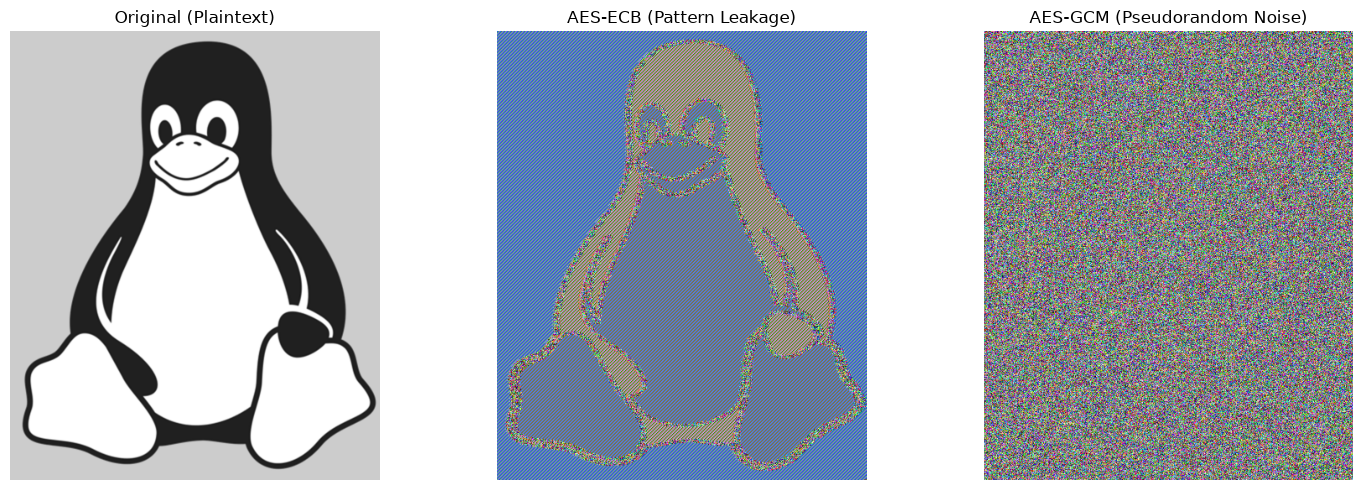

In [10]:
import io
import struct
import matplotlib.pyplot as plt
from PIL import Image
from Crypto.Cipher import AES

with open("./test.bmp", "rb") as f:
    raw = f.read()

pixel_offset = struct.unpack("<I", raw[10:14])[0]
header = raw[:pixel_offset]
pixel_data = raw[pixel_offset:]


key = bytes(16)

cipher_gcm = AES.new(key, AES.MODE_GCM)
ciphertext_gcm = cipher_gcm.encrypt(pixel_data)
bmp_gcm_bytes = header + ciphertext_gcm

pad_len = (16 - (len(pixel_data) % 16)) % 16
padded_pixels = pixel_data + b"\x00" * pad_len

cipher_ecb = AES.new(key, AES.MODE_ECB)
ciphertext_ecb = cipher_ecb.encrypt(padded_pixels)[:len(pixel_data)]
bmp_ecb_bytes = header + ciphertext_ecb

img_orig = Image.open(io.BytesIO(raw))
img_ecb  = Image.open(io.BytesIO(bmp_ecb_bytes))
img_gcm  = Image.open(io.BytesIO(bmp_gcm_bytes))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_orig)
axes[0].set_title("Original (Plaintext)")
axes[0].axis("off")

axes[1].imshow(img_ecb)
axes[1].set_title("AES-ECB (Pattern Leakage)")
axes[1].axis("off")

axes[2].imshow(img_gcm)
axes[2].set_title("AES-GCM (Pseudorandom Noise)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

#### Solución Programática

A continuación se trabajará sobre el archivo 8.txt, desde la fuente entregada en *CryptoPals*. Siguiendo el consejo de la fuente, se pueden identificar las porciones de los textos hexadecimales encryptados con el modo ECB, ya que su determinismo provoca consistencia entre entrada y salida. A una misma entrada para cifrar, se produce siempre la misma salida.

De todas las líneas cifradas y convertidas en formato hexadecimal, la línea que esté encriptada en AES modo ECB presentará entonces bloques repetidos.
Para descartar esta línea, se buscará la línea que tenga más repeticiones de bloques entre todas.

In [26]:
lineas = []

with open("./8.txt", "r") as f:
    for linea in f:
        lineas.append(linea.strip())

line_counter = 0
count_per_lines = [0]*len(lineas) # Para guardar la cantidad máxima de bloques repetidos por línea

for linea in lineas:
    
    # Un byte son dos caracteres
    # ECB usa bloques de 16 bytes
    # Debemos ver repeticiones en bloques, es decir, 32 caracteres por bloque
    tamano_linea = len(linea)
    i = 0
    block_counter = {}

    for _ in range(int(tamano_linea/32)):
        bloque = linea[i:i+32]
        
        if bloque in block_counter:
            block_counter[bloque]+=1
        else:
            block_counter[bloque]=1

        i+=32
    counts = block_counter.values()
    count_per_lines[line_counter] = max(counts)
    line_counter+=1

indice_linea_maximas_repeticiones = count_per_lines.index(max(count_per_lines))
print(f"Línea con valor máximo de repeticiones: Línea nro. {indice_linea_maximas_repeticiones}")
print(f"La línea per se: {lineas[indice_linea_maximas_repeticiones]}")
print(f"Cantidad de bloques repetidos en tal línea: {count_per_lines[indice_linea_maximas_repeticiones]}")

Línea con valor máximo de repeticiones: Línea nro. 132
La línea per se: d880619740a8a19b7840a8a31c810a3d08649af70dc06f4fd5d2d69c744cd283e2dd052f6b641dbf9d11b0348542bb5708649af70dc06f4fd5d2d69c744cd2839475c9dfdbc1d46597949d9c7e82bf5a08649af70dc06f4fd5d2d69c744cd28397a93eab8d6aecd566489154789a6b0308649af70dc06f4fd5d2d69c744cd283d403180c98c8f6db1f2a3f9c4040deb0ab51b29933f2c123c58386b06fba186a
Cantidad de bloques repetidos en tal línea: 4


* **Bits y Bytes:** Desde la distribución de Python v3 es posible utilizar el tipo de dato bytes(). Este tipo de datos representa un secuencia de valores en el rango desde 0 hasta 255 (8 bits) que son almacenados de manera inalterable. 

In [12]:
#bits
mybyte1 = int('11001000',2)
mybyte2 = int('00001000',2)
print(mybyte2 ^ mybyte1)  # a XOR b
print(mybyte2 or mybyte1) # a OR b
print(mybyte2 and mybyte1)  # a AND b
#bytes
mybyte3 = bytes(4) #inmutable  -> help(bytes)
print(mybyte3)
myarray = [mybyte3[i] for i in mybyte3]
print (myarray)    
print (type(myarray))

192
8
200
b'\x00\x00\x00\x00'
[0, 0, 0, 0]
<class 'list'>


* **ByteArray:** Complementariamente a bytes() está el tipo de datos bytearray() que sí crea un objeto alterable. La representación de los datos puede cambiar de acuerdo al sistema. Por ejemplo, el orden de los bytes cambia según el formato Endian, los valores más grandes primero (big endian), si no los pequeños primero (little endian). Otro ejemplo, sabemos que un byte no necesita ser firmado (unsigned) para representar datos en el rango positivo entre 0 y 255. Sin embargo, si fuese necesario representar valores en el rango -128 hasta +127, los bytes deben ser firmados (signed) para soportar un recorrido negativo. Ref.: https://docs.python.org/3/library/stdtypes.html

In [13]:
#bloques
mybytestream = [255,255,255,255] 
myblock = bytearray(mybytestream)
print(myblock[:2],'y',myblock[-2:])
print(bytearray(str(myblock),'utf-8'))

#formato
k = bytes([128,192,240,255])
print(k[1:2] , '=', bytes(k[1:2]))
ki = int.from_bytes(k[1:2], byteorder='big', signed=False)
kj = int.from_bytes(k[1:2], byteorder='little', signed=True)
print(ki, '!=', kj)

bytearray(b'\xff\xff') y bytearray(b'\xff\xff')
bytearray(b"bytearray(b\'\\xff\\xff\\xff\\xff\')")
b'\xc0' = b'\xc0'
192 != -64


* **Cifrado de Bloques:** Sabemos que AES opera en bytes y que utiliza múltiples tamaños de llave, así como un número variable de ciclos e incluso soporta múltiples bloques desde 128bits hasta 256bits. Sin embargo, ¿Qué sucede cuando el bloque tiende a ser pequeño? analice los eventuales riesgos del siguiente ejemplo.

In [14]:
import numpy as np
import string
def funcionF(a,b):
    K = np.array([1,1,0,0,1,1,0,0])
    X = ((a + b) % 2) ^ K   
    return X 
def funcionR(a,b):
    A_str = ''.join(str(x) for x in a)
    B_str = ''.join(str(x) for x in b)
    return (int(A_str,2),int(B_str,2))
M = '1111000011111111'
bloques = [M[i:i+8] for i in range(0,len(M),8)]
bloqueA = np.array(list(f'{int(bloques[0],2):b}'), dtype=int)
bloqueB = np.array(list(f'{int(bloques[1],2):b}'), dtype=int)
print(bloqueA, 'y', bloqueB)
print(funcionR(bloqueA,bloqueB))
A, B = (bloqueA ^ funcionF(bloqueA,bloqueB)), (bloqueB ^ funcionF(bloqueA,bloqueB))
print(funcionR(A,B))
C1, C2 = (A ^ funcionF(A,B)), (B ^ funcionF(A,B))
print(funcionR(C1,C2))

[1 1 1 1 0 0 0 0] y [1 1 1 1 1 1 1 1]
(240, 255)
(51, 60)
(240, 255)


#### Análisis respectivo

En el código se evidencian dos bloques binarios, siendo encriptados y desencriptados trivialmente con una llave sencilla de 8 bits y trabajando con bloques muy pequeños, de 8 bits cada uno también.

La seguridad de este ejemplo es de *n=8*, es decir, es en extremo sencillo romper este cifrado mediante un ataque de fuerza bruta o *búsqueda exhaustiva*.

Además, al trabajarse con bloques de 8 bits, cada bloque puede tomar un valor entre 0 y 255. Así cada bloque se puede mapear a un carácter del código ASCII, así pudiéndose crear un libro o mapeo entre cada bloque encriptado y su carácter ASCII correspondiente, como si de un cifrado por sustitución se tratase. 

Con el mismo argumento anterior, se puede realizar un ataque de frecuencias, viéndose repeticiones altas para letras (en español) como la *e*, o *a*.


* **Doble Cifrado:** Si la debilidad del algoritmo DES recae en la longitud de llave, entonces ¿Un doble cifrado qué más seguro podría ser? analice el siguiente código.

In [15]:
K0 = bytes([254,255,254,255])  
K1 = bytes([254,255,254,255])  
M = bytes([128,192,240,255])

def funcionW(m):
    B = [bin(M[i]) for i in range(len(M))]
    T = [B[i][2:] for i in range(len(B))]
    return T

def funcionQ(k):
    S = [bin(k[n]) for n in range(len(k))]
    V = [S[n][2:] for n in range(len(S))]
    return V

def funcionE(x,y,z):
    return ((x ^ y)^z)

MX = np.zeros((4,8),dtype=int)
KX0, KX1 = np.zeros((4,8),dtype=int), np.zeros((4,8),dtype=int)

for i in range(0,4):
    for j in range (0,8):         
        t0 = funcionW(M)[i][j:j+1]
        t1, t2 = funcionQ(K0)[i][j:j+1], funcionQ(K1)[i][j:j+1]
        MX[i][j] = t0
        KX0[i][j], KX1[i][j] = t1, t2

print(funcionE(MX,KX0,KX1))

[[1 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0]
 [1 1 1 1 0 0 0 0]
 [1 1 1 1 1 1 1 1]]


#### Análisis de doble cifra

En el código se observa la aplicación de un doble cifrado utilizando la operación lógica XOR y dos llaves exactamente iguales ($K_0$ y $K_1$). 

Debido a las propiedades matemáticas del XOR, al aplicar la operación dos veces con el mismo valor, esta se anula a sí misma y devuelve el texto original, por lo que no se añade ninguna capa de seguridad.
Incluso si las llaves fueran distintas, el doble cifrado con operaciones lineales (como XOR) equivale matemáticamente a un cifrado simple con una sola llave combinada. 

Llevando esto a un escenario real como el algoritmo DES, cifrar dos veces tampoco duplica el tamaño de la llave (de 56 a 112 bits) en la práctica. Esto ocurre por la existencia del ataque Meet-in-the-Middle (Encuentro en el medio), el cual permite romper el doble cifrado en casi el mismo tiempo que tomaría romper un cifrado simple, demostrando que esta técnica no es efectiva para mejorar la seguridad.

* **Perfilamiento del Tiempo:** Así como el efecto avalancha intenta estimar el porcentaje de difusión de los bits permutados. El perfilamiento del tiempo intenta medir la eficiencia o el tiempo que tarda la ejecución de alguna rutina, ya sea una línea o un módulo.

| Referencia |
| :--- |
| [Python Profilers](https://docs.python.org/3.15/library/profiling.html)|
| [Python Execution Time](https://docs.python.org/3.15/library/timeit.html)|

In [16]:
import timeit
import numpy as np

p = [2, 3, 7, 11, 13]
r = [2, 4, 6, 8, 10]
large_a, large_b = [1, 2] * 10**5, [2, 3] * 10**5

a_np = np.array(p)
large_a_np = np.array(large_a)
large_b_np = np.array(large_b)

%timeit -r 5 -n 1000 [x * 5 for x in p]
%timeit -r 5 -n 1000 a_np * 5

%timeit -r 3 -n 5 [sum(x) for x in zip(large_a, large_b)]
%timeit -r 7 -n 50 large_a_np + large_b_np

setup_code = """
import numpy as np
large_a, large_b = [1, 2] * 10**5, [2, 3] * 10**5
large_a_np = np.array(large_a)
large_b_np = np.array(large_b)
"""

py_zip_time = timeit.timeit(
    stmt="[sum(x) for x in zip(large_a, large_b)]",
    setup=setup_code,
    number=10
)

np_add_time = timeit.timeit(
    stmt="large_a_np + large_b_np",
    setup=setup_code,
    number=10
)

print(f"Pure Python (zip + sum): {py_zip_time / 10:.5f} s per loop")
print(f"NumPy SIMD Vectorized:   {np_add_time / 10:.5f} s per loop")
print(f"Speedup Factor:          {py_zip_time / np_add_time:.1f}x")

114 ns ± 4.62 ns per loop (mean ± std. dev. of 5 runs, 1,000 loops each)
670 ns ± 45.5 ns per loop (mean ± std. dev. of 5 runs, 1,000 loops each)
10.5 ms ± 260 μs per loop (mean ± std. dev. of 3 runs, 5 loops each)
46.1 μs ± 6.6 μs per loop (mean ± std. dev. of 7 runs, 50 loops each)
Pure Python (zip + sum): 0.00978 s per loop
NumPy SIMD Vectorized:   0.00006 s per loop
Speedup Factor:          157.5x


In [17]:
import cProfile
import pstats
import io

def benchmark_pure_python(a, b):
    return [sum(pair) for pair in zip(a, b)]

def benchmark_numpy(a_np, b_np):
    return a_np + b_np

pr = cProfile.Profile()
pr.enable()
result_py = benchmark_pure_python(large_a, large_b)
pr.disable()

s = io.StringIO()
ps = pstats.Stats(pr, stream=s).sort_stats(pstats.SortKey.CUMULATIVE)
ps.print_stats(10)
print(s.getvalue())

         200475 function calls (200469 primitive calls) in 0.035 seconds

   Ordered by: cumulative time
   List reduced from 94 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000    0.029    0.014 /opt/conda/lib/python3.13/asyncio/base_events.py:1980(_run_once)
      3/2    0.000    0.000    0.028    0.014 /opt/conda/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3739(run_code)
      3/2    0.004    0.001    0.028    0.014 {built-in method builtins.exec}
        1    0.008    0.008    0.015    0.015 {method 'execute' of 'sqlite3.Connection' objects}
   200000    0.015    0.000    0.015    0.000 {built-in method builtins.sum}
        1    0.007    0.007    0.013    0.013 /tmp/ipykernel_3837611/2244099021.py:5(benchmark_pure_python)
        2    0.000    0.000    0.000    0.000 /opt/conda/lib/python3.13/asyncio/events.py:87(_run)
        2    0.000    0.000    0.000    0.000 {method 'run' of '

* **Padding:** En los modos de cifrado por bloques se necesita que el mensaje en texto plano tenga un valor múltiplo con respecto al tamaño del bloque, y de no ser así debemos completar el bloque para satisfacer la operación.

In [18]:
v = np.arange(1,9,1)
mv = v.reshape((2,4))
print(mv)
np.pad(mv,(0,4),'constant', constant_values=(0))

k = bytes([254,255]) 
mk = np.array(bytearray(k),dtype=int)
print(mk)
np.pad(mk,(0,4),'constant', constant_values=(0))
#np.pad()

[[1 2 3 4]
 [5 6 7 8]]
[254 255]


array([254, 255,   0,   0,   0,   0])

### **Actividad 3**: En AES, los bytes se tratan como elementos del Galois Field $GF(2^8)$ módulo el polinomio irreducible:

$$P(x) = x^8 + x^4 + x^3 + x + 1 \quad (\texttt{0x11B})$$

El paso no lineal del S-Box de AES se basa en calcular el inverso multiplicativo (multiplicative inverse) $a^{-1} \in GF(2^8)$ tal que $a \cdot a^{-1} \equiv 1 \pmod{P(x)}$.

implementa xtime(b) para multiplicar un byte por $x \pmod{P(x)}$ utilizando únicamente bit-shifts y operaciones XOR:

In [19]:
def xtime(b: int) -> int:
    return ((b << 1) ^ 0x1B) & 0xFF if (b & 0x80) else (b << 1) & 0xFF


Utiliza xtime para construir un multiplicador general gmult(a, b) para todo par de bytes $a, b \in GF(2^8)$.

Por el Pequeño Teorema de Fermat en campos finitos (finite fields), para cualquier elemento no nulo $\alpha \in GF(2^8)$:

$$\alpha^{2^8 - 1} = \alpha^{255} = 1 \implies \alpha^{-1} = \alpha^{254}$$

Implementa gf_inv(a) utilizando ya sea el Extended Euclidean Algorithm para polinomios o exponenciación binaria (square-and-multiply) para computar $a^{254}$.

Verifica que gmult(a, gf_inv(a)) == 1 para todo $a \in [1, 255]$, definiendo $0^{-1} = 0$.

In [20]:
# Escriba aquí su código y markdown
def gmult(a: int, b: int) -> int:
    result = 0
    for _ in range(8):
        if b & 1:
            result ^= a        # suma en GF(2^8) = XOR
        a = xtime(a)           # a <- a·x mod P(x)
        b >>= 1
    return result

def gf_inv(a: int) -> int:
    if a == 0:
        return 0               # convención 0^-1 = 0
    result, base, exp = 1, a, 254
    while exp:                 # square-and-multiply para a^254
        if exp & 1:
            result = gmult(result, base)
        base = gmult(base, base)
        exp >>= 1
    return result
    #Verificaciones
assert gmult(0x57, 0x83) == 0xC1          
assert gmult(0x57, 0x13) == 0xFE          
assert xtime(0x80) == 0x1B
assert gf_inv(0) == 0
fallos = [a for a in range(1, 256) if gmult(a, gf_inv(a)) != 1]
print("Fallos:", fallos)
print("No hay errores en [1, 255]" if not fallos else "Hay errores")
print(f"gf_inv(0x53) = {gf_inv(0x53):#04x}  (esperado 0xca)")
assert gf_inv(0x53) == 0xCA
# consistencia: conmutatividad y distributividad (muestra)
import random
for _ in range(2000):
    a,b,c = (random.randrange(256) for _ in range(3))
    assert gmult(a,b)==gmult(b,a)
    assert gmult(a,b^c)==gmult(a,b)^gmult(a,c)
print("Conmutatividad y distributividad OK")

Fallos: []
No hay errores en [1, 255]
gf_inv(0x53) = 0xca  (esperado 0xca)
Conmutatividad y distributividad OK


### **Actividad 4**: Aplica la transformación afín (affine transformation) de AES sobre $GF(2)$ al resultado de la inversión:

$$s_i' = s_i \oplus s_{(i+4) \bmod 8} \oplus s_{(i+5) \bmod 8} \oplus s_{(i+6) \bmod 8} \oplus s_{(i+7) \bmod 8} \oplus c_i$$

donde $c = \texttt{0x63}$

¿Por qué AES utiliza tanto la inversión de campo en $GF(2^8)$ como la transformación afín a nivel de bits, en lugar de utilizar únicamente la inversión algebraica?
(*Hint:* Investigar ataques algebraicos y el grado del polinomio de interpolación).

Se aplica la transformación afín a los bits del inverso de la Actividad 3, con $c = \texttt{0x63}$. Si se hace para los 256 bytes se obtiene la S-box de AES.

In [21]:
C = 0x63

def bit(x: int, i: int) -> int:
    return (x >> i) & 1

def affine(s: int, c: int = C) -> int:
    # Transformación afín de AES sobre GF(2), tal como la define el enunciado
    out = 0
    for i in range(8):
        s_i = (bit(s, i) ^ bit(s, (i + 4) % 8) ^ bit(s, (i + 5) % 8)
               ^ bit(s, (i + 6) % 8) ^ bit(s, (i + 7) % 8) ^ bit(c, i))
        out |= s_i << i
    return out

def sub_byte(a: int) -> int:
    return affine(gf_inv(a))

Ejemplo con `0x53` (el mismo de FIPS-197):

In [22]:
a = 0x53
s = gf_inv(a)
s_out = affine(s)

print(f"a = 0x{a:02X}  ->  s = a^-1 = 0x{s:02X} = {s:08b}")
print(f"\n i | s_i s_(i+4) s_(i+5) s_(i+6) s_(i+7) c_i | s'_i")
for i in range(8):
    t = [bit(s, i), bit(s, (i+4) % 8), bit(s, (i+5) % 8),
         bit(s, (i+6) % 8), bit(s, (i+7) % 8), bit(C, i)]
    print(f" {i} |  {t[0]}     {t[1]}       {t[2]}       {t[3]}       {t[4]}     {t[5]}  |  {bit(s_out, i)}")
print(f"\nS(0x{a:02X}) = 0x{s_out:02X} = {s_out:08b}")

a = 0x53  ->  s = a^-1 = 0xCA = 11001010

 i | s_i s_(i+4) s_(i+5) s_(i+6) s_(i+7) c_i | s'_i
 0 |  0     0       0       1       1     1  |  1
 1 |  1     0       1       1       0     1  |  0
 2 |  0     1       1       0       1     0  |  1
 3 |  1     1       0       1       0     0  |  1
 4 |  0     0       1       0       1     0  |  0
 5 |  0     1       0       1       0     1  |  1
 6 |  1     0       1       0       0     1  |  1
 7 |  1     1       0       0       1     0  |  1

S(0x53) = 0xED = 11101101


S-box completa, comparada con los valores de FIPS-197:

In [23]:
rotl = lambda v, k: ((v << k) | (v >> (8 - k))) & 0xFF
assert all(affine(v) == v ^ rotl(v, 1) ^ rotl(v, 2) ^ rotl(v, 3) ^ rotl(v, 4) ^ C
           for v in range(256))

sbox = [sub_byte(a) for a in range(256)]

assert sbox[:16] == [0x63, 0x7C, 0x77, 0x7B, 0xF2, 0x6B, 0x6F, 0xC5,
                     0x30, 0x01, 0x67, 0x2B, 0xFE, 0xD7, 0xAB, 0x76]   # fila 0 de FIPS-197
assert sbox[0x53] == 0xED and sbox[0xFF] == 0x16
assert len(set(sbox)) == 256
print("S-box OK: coincide con FIPS-197 y es biyectiva\n")

print("    " + " ".join(f" {c:x}" for c in range(16)))
for fila in range(16):
    print(f" {fila:x} | " + " ".join(f"{sbox[16*fila + c]:02x}" for c in range(16)))

S-box OK: coincide con FIPS-197 y es biyectiva

     0  1  2  3  4  5  6  7  8  9  a  b  c  d  e  f
 0 | 63 7c 77 7b f2 6b 6f c5 30 01 67 2b fe d7 ab 76
 1 | ca 82 c9 7d fa 59 47 f0 ad d4 a2 af 9c a4 72 c0
 2 | b7 fd 93 26 36 3f f7 cc 34 a5 e5 f1 71 d8 31 15
 3 | 04 c7 23 c3 18 96 05 9a 07 12 80 e2 eb 27 b2 75
 4 | 09 83 2c 1a 1b 6e 5a a0 52 3b d6 b3 29 e3 2f 84
 5 | 53 d1 00 ed 20 fc b1 5b 6a cb be 39 4a 4c 58 cf
 6 | d0 ef aa fb 43 4d 33 85 45 f9 02 7f 50 3c 9f a8
 7 | 51 a3 40 8f 92 9d 38 f5 bc b6 da 21 10 ff f3 d2
 8 | cd 0c 13 ec 5f 97 44 17 c4 a7 7e 3d 64 5d 19 73
 9 | 60 81 4f dc 22 2a 90 88 46 ee b8 14 de 5e 0b db
 a | e0 32 3a 0a 49 06 24 5c c2 d3 ac 62 91 95 e4 79
 b | e7 c8 37 6d 8d d5 4e a9 6c 56 f4 ea 65 7a ae 08
 c | ba 78 25 2e 1c a6 b4 c6 e8 dd 74 1f 4b bd 8b 8a
 d | 70 3e b5 66 48 03 f6 0e 61 35 57 b9 86 c1 1d 9e
 e | e1 f8 98 11 69 d9 8e 94 9b 1e 87 e9 ce 55 28 df
 f | 8c a1 89 0d bf e6 42 68 41 99 2d 0f b0 54 bb 16


Para responder la pregunta, se compara la inversión sola con la S-box completa: polinomio de interpolación, puntos fijos y uniformidad diferencial.

In [24]:
EXP, LOG = [0] * 510, [0] * 256
v = 1
for k in range(255):
    EXP[k] = EXP[k + 255] = v
    LOG[v] = k
    v = gmult(v, 0x03)

def interpolar(f):
    coef = {0: f(0)} if f(0) else {}
    for k in range(1, 256):
        acc = 0
        for a in range(1, 256):
            fa = f(a)
            if fa:
                acc ^= EXP[(LOG[fa] + LOG[a] * (255 - k)) % 255]
        if k == 255:
            acc ^= f(0)       # término con 0^0 = 1
        if acc:
            coef[k] = acc
    return coef

def mostrar(coef):
    return " + ".join(f"{c:02x}·x^{k}" for k, c in sorted(coef.items(), reverse=True))

p_inv = interpolar(gf_inv)
p_sbox = interpolar(lambda a: sbox[a])
print(f"Inversión ({len(p_inv)} término):\n  {mostrar(p_inv)}\n")
print(f"S-box AES ({len(p_sbox)} términos):\n  {mostrar(p_sbox)}")

Inversión (1 término):
  01·x^254

S-box AES (9 términos):
  05·x^254 + 09·x^253 + f9·x^251 + 25·x^247 + f4·x^239 + 01·x^223 + b5·x^191 + 8f·x^127 + 63·x^0


In [25]:
def uniformidad_diferencial(f):
    peor = 0
    for d in range(1, 256):
        cuenta = [0] * 256
        for a in range(256):
            cuenta[f(a) ^ f(a ^ d)] += 1
        peor = max(peor, max(cuenta))
    return peor

S = lambda a: sbox[a]
print("Puntos fijos inversión :", [hex(a) for a in range(256) if gf_inv(a) == a])
print("Puntos fijos S-box     :", [hex(a) for a in range(256) if S(a) == a])
print("Opuestos S(a) = ~a     :", [hex(a) for a in range(256) if S(a) == a ^ 0xFF])
print("Uniformidad diferencial inversión:", uniformidad_diferencial(gf_inv))
print("Uniformidad diferencial S-box    :", uniformidad_diferencial(S))

Puntos fijos inversión : ['0x0', '0x1']
Puntos fijos S-box     : []
Opuestos S(a) = ~a     : []
Uniformidad diferencial inversión: 4
Uniformidad diferencial S-box    : 4


**Resultados:** $S(\texttt{0x53}) = \texttt{0xED}$ y la S-box coincide con FIPS-197. La inversión sola es $x^{254}$ (1 término); con la afín, el polinomio pasa a 9 términos. La inversión tiene puntos fijos (0 y 1) y la S-box no tiene ninguno. La uniformidad diferencial es 4 en ambos casos.

**¿Por qué usar las dos?**

La inversión es la que le da la no linealidad a AES (uniformidad diferencial 4, no linealidad 112), y por eso resiste bien el criptoanálisis diferencial y lineal. El problema es que algebraicamente es muy simple: como polinomio en $GF(2^8)$ es solo $x^{254}$, o sea $1/x$. Como el resto de AES (MixColumns, AddRoundKey) también trabaja en $GF(2^8)$, todo el cifrado quedaría como una expresión algebraica bastante simple. Eso facilita los ataques de interpolación (reconstruir el polinomio del cifrado a partir de pares texto plano/cifrado) y los ataques algebraicos (plantear el cifrado como un sistema de ecuaciones y resolverlo).

La transformación afín es lineal a nivel de bits pero no en $GF(2^8)$, así que rompe esa estructura: el polinomio pasa de 1 a 9 términos. Además elimina los puntos fijos (gracias a la constante `0x63`, el 0 ya no va a 0) y es invertible, así que la S-box sigue siendo una permutación.

La afín no mejora la resistencia diferencial (sigue en 4); eso lo aporta solo la inversión. Cada paso cumple una función distinta.

### Fin de la Tarea!!!